In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('data/Resultados_únicos_Saber_11_Santander.csv',encoding='UTF-8')
data.head()

,PERIODO,ESTU_TIPODOCUMENTO,ESTU_CONSECUTIVO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,...,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20194,TI,SB11201940226736,URBANO,N,A,TÉCNICO/ACADÉMICO,168001002421,168001002421,68,...,Si,Si,Si,A2,61.0,64.0,49.0,59.0,63.0,295.0
1,20194,TI,SB11201940226736,URBANO,N,A,TÉCNICO/ACADÉMICO,168001002421,168001002421,68,...,Si,Si,Si,A2,61.0,64.0,49.0,59.0,63.0,295.0
2,20172,TI,SB11201720104447,URBANO,N,A,TÉCNICO/ACADÉMICO,168307001002,168307001002,68,...,No,No,Si,A-,47.0,59.0,64.0,59.0,68.0,307.0
3,20122,TI,SB11201220024292,URBANO,N,A,ACADÉMICO,368655001261,368655001261,68,...,No,No,Si,A1,46.0,45.0,NaN,NaN,NaN,NaN
4,20122,TI,SB11201220007144,URBANO,N,A,ACADÉMICO,368001002837,368001002837,68,...,NaN,Si,Si,A1,51.0,61.0,NaN,NaN,NaN,NaN


In [4]:
data.shape

(346512, 51)

In [5]:
data.columns

Index(['PERIODO', 'ESTU_TIPODOCUMENTO', 'ESTU_CONSECUTIVO',
       'COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_CALENDARIO',
       'COLE_CARACTER', 'COLE_COD_DANE_ESTABLECIMIENTO', 'COLE_COD_DANE_SEDE',
       'COLE_COD_DEPTO_UBICACION', 'COLE_COD_MCPIO_UBICACION',
       'COLE_CODIGO_ICFES', 'COLE_DEPTO_UBICACION', 'COLE_GENERO',
       'COLE_JORNADA', 'COLE_MCPIO_UBICACION', 'COLE_NATURALEZA',
       'COLE_NOMBRE_ESTABLECIMIENTO', 'COLE_NOMBRE_SEDE',
       'COLE_SEDE_PRINCIPAL', 'ESTU_COD_DEPTO_PRESENTACION',
       'ESTU_COD_MCPIO_PRESENTACION', 'ESTU_COD_RESIDE_DEPTO',
       'ESTU_COD_RESIDE_MCPIO', 'ESTU_DEPTO_PRESENTACION', 'ESTU_DEPTO_RESIDE',
       'ESTU_ESTADOINVESTIGACION', 'ESTU_ESTUDIANTE', 'ESTU_FECHANACIMIENTO',
       'ESTU_GENERO', 'ESTU_MCPIO_PRESENTACION', 'ESTU_MCPIO_RESIDE',
       'ESTU_NACIONALIDAD', 'ESTU_PAIS_RESIDE', 'ESTU_PRIVADO_LIBERTAD',
       'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE',
       'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSO

In [6]:
data["DESEMP_INGLES"].value_counts(dropna=False)

DESEMP_INGLES
A-     159042
A1     111903
A2      42638
B1      24355
B+       8538
NaN        36
Name: count, dtype: int64

La mayoría de estudiantes se concentra en los niveles A- y A1, mientras que los niveles superiores B1 y B+ tienen una participación mucho menor. Esto indica que el modelo de clasificación tendrá que manejar una variable objetivo desbalanceada.

In [7]:
data["DESEMP_INGLES"].value_counts(normalize=True) * 100

DESEMP_INGLES
A-    45.902747
A1    32.297475
A2    12.306191
B1     7.029347
B+     2.464240
Name: proportion, dtype: float64

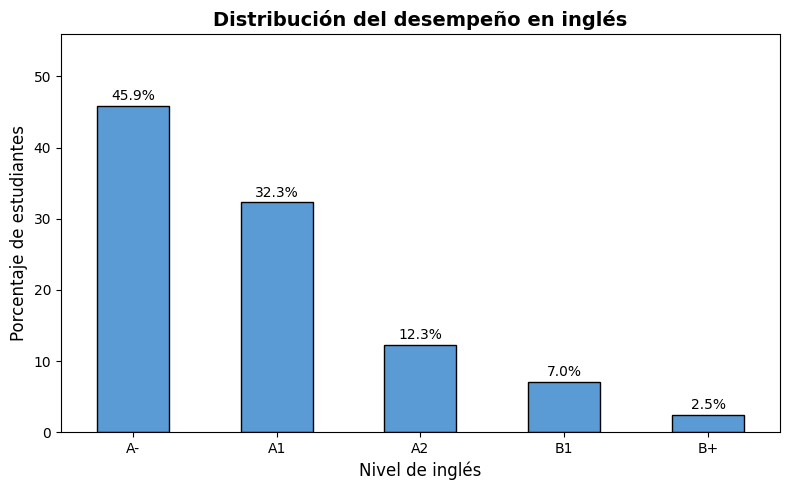

In [8]:
# Gráfica de la distribución del desempeño en inglés
niveles = ["A-", "A1", "A2", "B1", "B+"]

distribucion = (
    data["DESEMP_INGLES"]
    .value_counts(normalize=True)
    .reindex(niveles)
    .fillna(0)
    * 100
)

plt.figure(figsize=(8, 5))
ax = distribucion.plot(
    kind="bar",
    color="#5B9BD5",
    edgecolor="black"
)

plt.title("Distribución del desempeño en inglés", fontsize=14, fontweight="bold")
plt.xlabel("Nivel de inglés", fontsize=12)
plt.ylabel("Porcentaje de estudiantes", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, distribucion.max() + 10)

for i, value in enumerate(distribucion):
    ax.text(i, value + 0.8, f"{value:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
duplicados_completos = data.duplicated().sum()

print("Duplicados completos:", duplicados_completos)
print("Porcentaje de duplicados completos:", round(duplicados_completos / len(data) * 100, 2), "%")

Duplicados completos: 73529
Porcentaje de duplicados completos: 21.22 %


In [10]:
nulos = data.isnull().mean().sort_values(ascending=False) * 100
nulos

PUNT_C_NATURALES                 39.394018
PUNT_LECTURA_CRITICA             39.394018
PUNT_GLOBAL                      39.394018
PUNT_SOCIALES_CIUDADANAS         39.394018
COLE_BILINGUE                    12.312128
FAMI_EDUCACIONPADRE               2.976809
FAMI_EDUCACIONMADRE               2.973923
FAMI_ESTRATOVIVIENDA              2.556910
FAMI_TIENECOMPUTADOR              2.407420
FAMI_TIENEINTERNET                2.182320
FAMI_TIENEAUTOMOVIL               1.595616
FAMI_CUARTOSHOGAR                 1.548576
FAMI_TIENELAVADORA                1.532414
FAMI_PERSONASHOGAR                1.509616
COLE_CARACTER                     1.196784
ESTU_COD_RESIDE_MCPIO             0.539952
ESTU_DEPTO_RESIDE                 0.539952
ESTU_COD_RESIDE_DEPTO             0.539952
ESTU_MCPIO_RESIDE                 0.539952
COLE_CODIGO_ICFES                 0.508496
ESTU_GENERO                       0.037805
COLE_CALENDARIO                   0.028859
DESEMP_INGLES                     0.010389
COLE_AREA_U

In [11]:
data['DESEMP_INGLES'].isnull().mean() * 100

np.float64(0.0103892505887242)

In [12]:
tabla_naturaleza = pd.crosstab(
    data["COLE_NATURALEZA"],
    data["DESEMP_INGLES"],
    normalize="index"
) * 100

tabla_naturaleza

DESEMP_INGLES,A-,A1,A2,B+,B1
COLE_NATURALEZA,,,,,
NO OFICIAL,42.332003,23.684238,13.136970,7.161385,13.685403
OFICIAL,47.240948,35.525444,11.994842,0.703898,4.534868


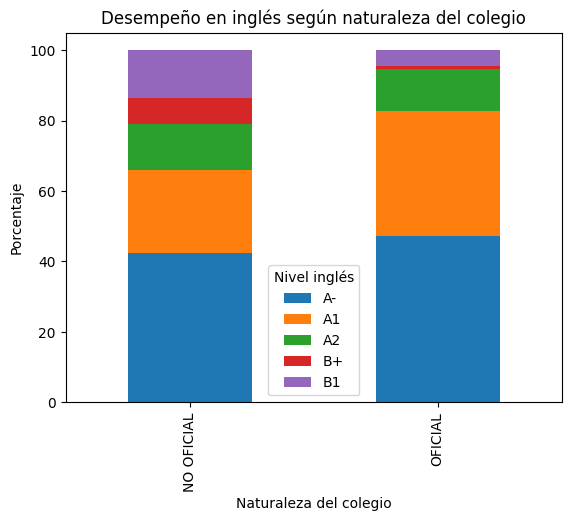

In [13]:
tabla_naturaleza.plot(kind="bar", stacked=True)

plt.title("Desempeño en inglés según naturaleza del colegio")
plt.xlabel("Naturaleza del colegio")
plt.ylabel("Porcentaje")
plt.legend(title="Nivel inglés")
plt.show()

In [14]:
tabla_bilingue = pd.crosstab(
    data["COLE_BILINGUE"],
    data["DESEMP_INGLES"],
    normalize="index"
) * 100

tabla_bilingue

DESEMP_INGLES,A-,A1,A2,B+,B1
COLE_BILINGUE,,,,,
N,44.430495,33.247431,12.822381,2.298489,7.201203
S,23.762376,11.933299,2.657634,45.075560,16.571131


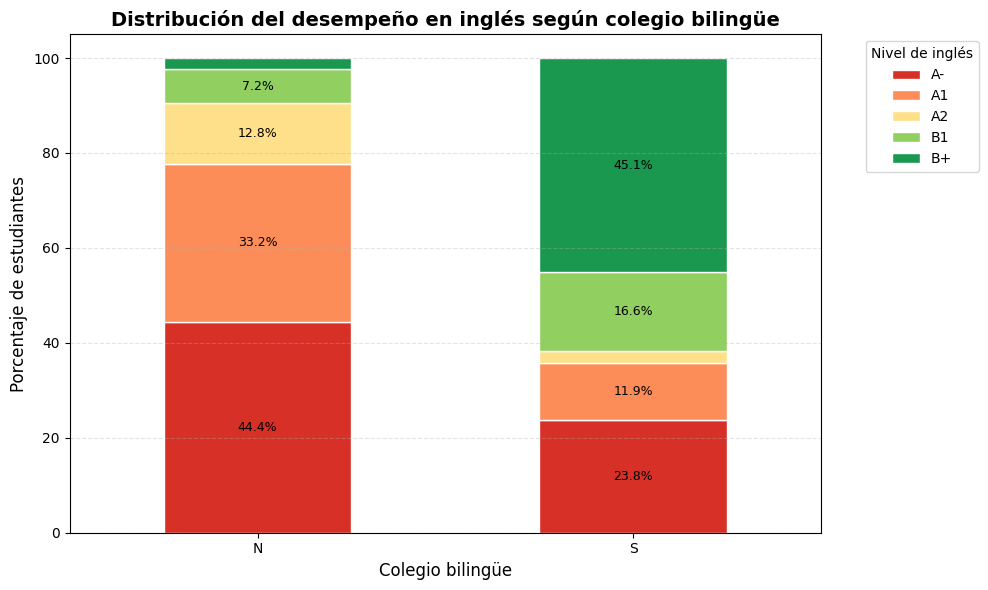

In [15]:
orden_niveles = ["A-", "A1", "A2", "B1", "B+"]

tabla_bilingue = tabla_bilingue[orden_niveles]

colores = [
    "#d73027",
    "#fc8d59",
    "#fee08b",
    "#91cf60",
    "#1a9850"
]

ax = tabla_bilingue.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=colores,
    edgecolor="white"
)

plt.title(
    "Distribución del desempeño en inglés según colegio bilingüe",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Colegio bilingüe", fontsize=12)
plt.ylabel("Porcentaje de estudiantes", fontsize=12)
plt.xticks(rotation=0)

plt.legend(
    title="Nivel de inglés",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.35)

# Agregar etiquetas de porcentaje dentro de cada segmento
for container in ax.containers:
    labels = [
        f"{v:.1f}%" if v > 3 else ""
        for v in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="black"
    )

plt.tight_layout()
plt.show()

In [16]:
tabla_computador = pd.crosstab(
    data["FAMI_TIENECOMPUTADOR"],
    data["DESEMP_INGLES"],
    normalize="index"
) * 100

tabla_computador

DESEMP_INGLES,A-,A1,A2,B+,B1
FAMI_TIENECOMPUTADOR,,,,,
No,59.865824,30.932257,7.148137,0.230135,1.823647
Si,35.846363,33.320496,15.987573,4.125908,10.719659


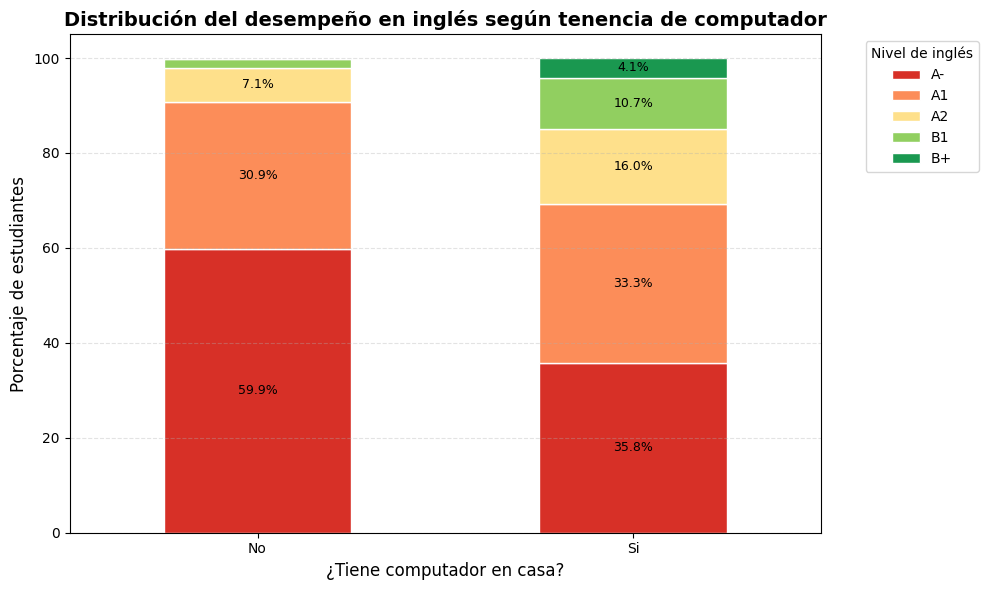

In [17]:
orden_niveles = ["A-", "A1", "A2", "B1", "B+"]

tabla_computador = tabla_computador[orden_niveles]

colores = [
    "#d73027",
    "#fc8d59",
    "#fee08b",
    "#91cf60",
    "#1a9850"
]

ax = tabla_computador.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=colores,
    edgecolor="white"
)

plt.title(
    "Distribución del desempeño en inglés según tenencia de computador",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("¿Tiene computador en casa?", fontsize=12)
plt.ylabel("Porcentaje de estudiantes", fontsize=12)
plt.xticks(rotation=0)

plt.legend(
    title="Nivel de inglés",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.35)

# Agregar etiquetas de porcentaje
for container in ax.containers:
    labels = [
        f"{v:.1f}%" if v > 3 else ""
        for v in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        color="black"
    )

plt.tight_layout()
plt.show()

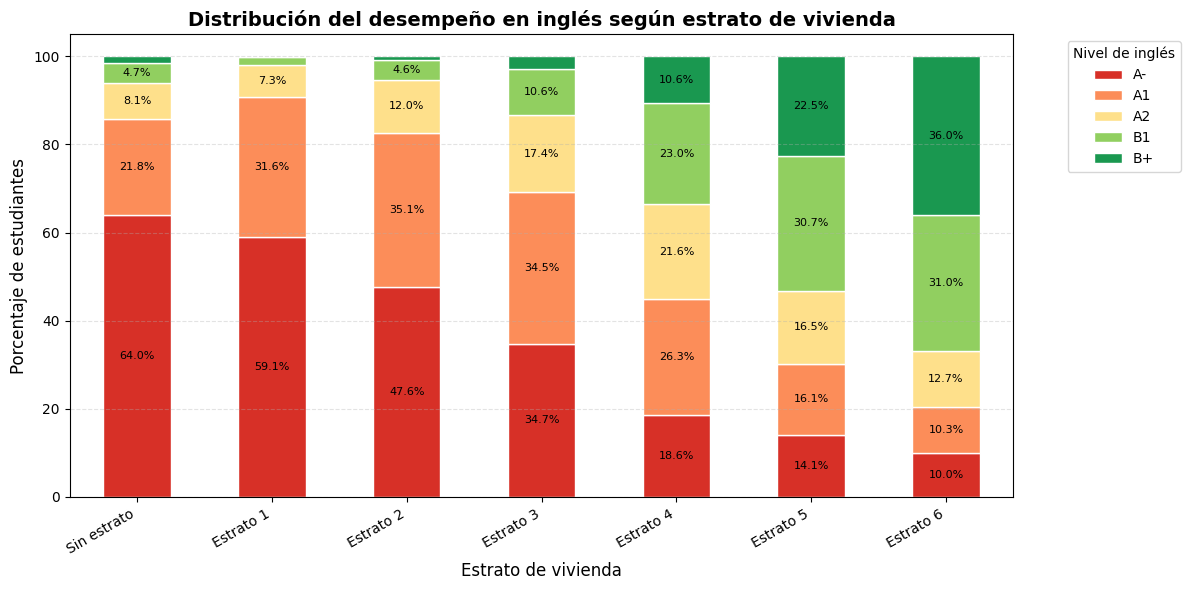

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear tabla porcentual por estrato
tabla_estrato = pd.crosstab(
    data["FAMI_ESTRATOVIVIENDA"],
    data["DESEMP_INGLES"],
    normalize="index"
) * 100

# Copia para graficar
tabla_estrato_graf = tabla_estrato.copy()

# Convertir índice a texto
tabla_estrato_graf.index = tabla_estrato_graf.index.astype(str)

# Renombrar categorías sin estrato o desconocidas
tabla_estrato_graf = tabla_estrato_graf.rename(index={
    "nan": "Sin estrato",
    "NaN": "Sin estrato",
    "Desconocido": "Sin estrato",
    "Sin Estrato": "Sin estrato",
    "SIN ESTRATO": "Sin estrato",
    "No sabe": "Sin estrato",
    "No Aplica": "Sin estrato"
})

# Orden recomendado de niveles de inglés
orden_niveles = ["A-", "A1", "A2", "B1", "B+"]

# Mantener solo los niveles que existan en la tabla
orden_niveles = [nivel for nivel in orden_niveles if nivel in tabla_estrato_graf.columns]
tabla_estrato_graf = tabla_estrato_graf[orden_niveles]

# Ordenar estratos dejando "Sin estrato" como primera barra
orden_estratos = [
    "Sin estrato",
    "Estrato 1",
    "Estrato 2",
    "Estrato 3",
    "Estrato 4",
    "Estrato 5",
    "Estrato 6"
]

# Mantener solo los estratos existentes
orden_estratos = [estrato for estrato in orden_estratos if estrato in tabla_estrato_graf.index]

# Agregar cualquier otra categoría al final
otros_estratos = [
    estrato for estrato in tabla_estrato_graf.index
    if estrato not in orden_estratos
]

tabla_estrato_graf = tabla_estrato_graf.loc[orden_estratos + otros_estratos]

# Colores de menor a mayor desempeño
colores = [
    "#d73027",  # A-
    "#fc8d59",  # A1
    "#fee08b",  # A2
    "#91cf60",  # B1
    "#1a9850"   # B+
]

# Crear gráfica
ax = tabla_estrato_graf.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=colores[:len(orden_niveles)],
    edgecolor="white"
)

# Títulos y etiquetas
plt.title(
    "Distribución del desempeño en inglés según estrato de vivienda",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Estrato de vivienda", fontsize=12)
plt.ylabel("Porcentaje de estudiantes", fontsize=12)

plt.xticks(rotation=30, ha="right")
plt.yticks(fontsize=10)

# Leyenda
plt.legend(
    title="Nivel de inglés",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Cuadrícula suave
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Agregar porcentajes dentro de las barras
for container in ax.containers:
    labels = [
        f"{valor:.1f}%" if valor >= 3 else ""
        for valor in container.datavalues
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8,
        color="black"
    )

plt.tight_layout()
plt.show()

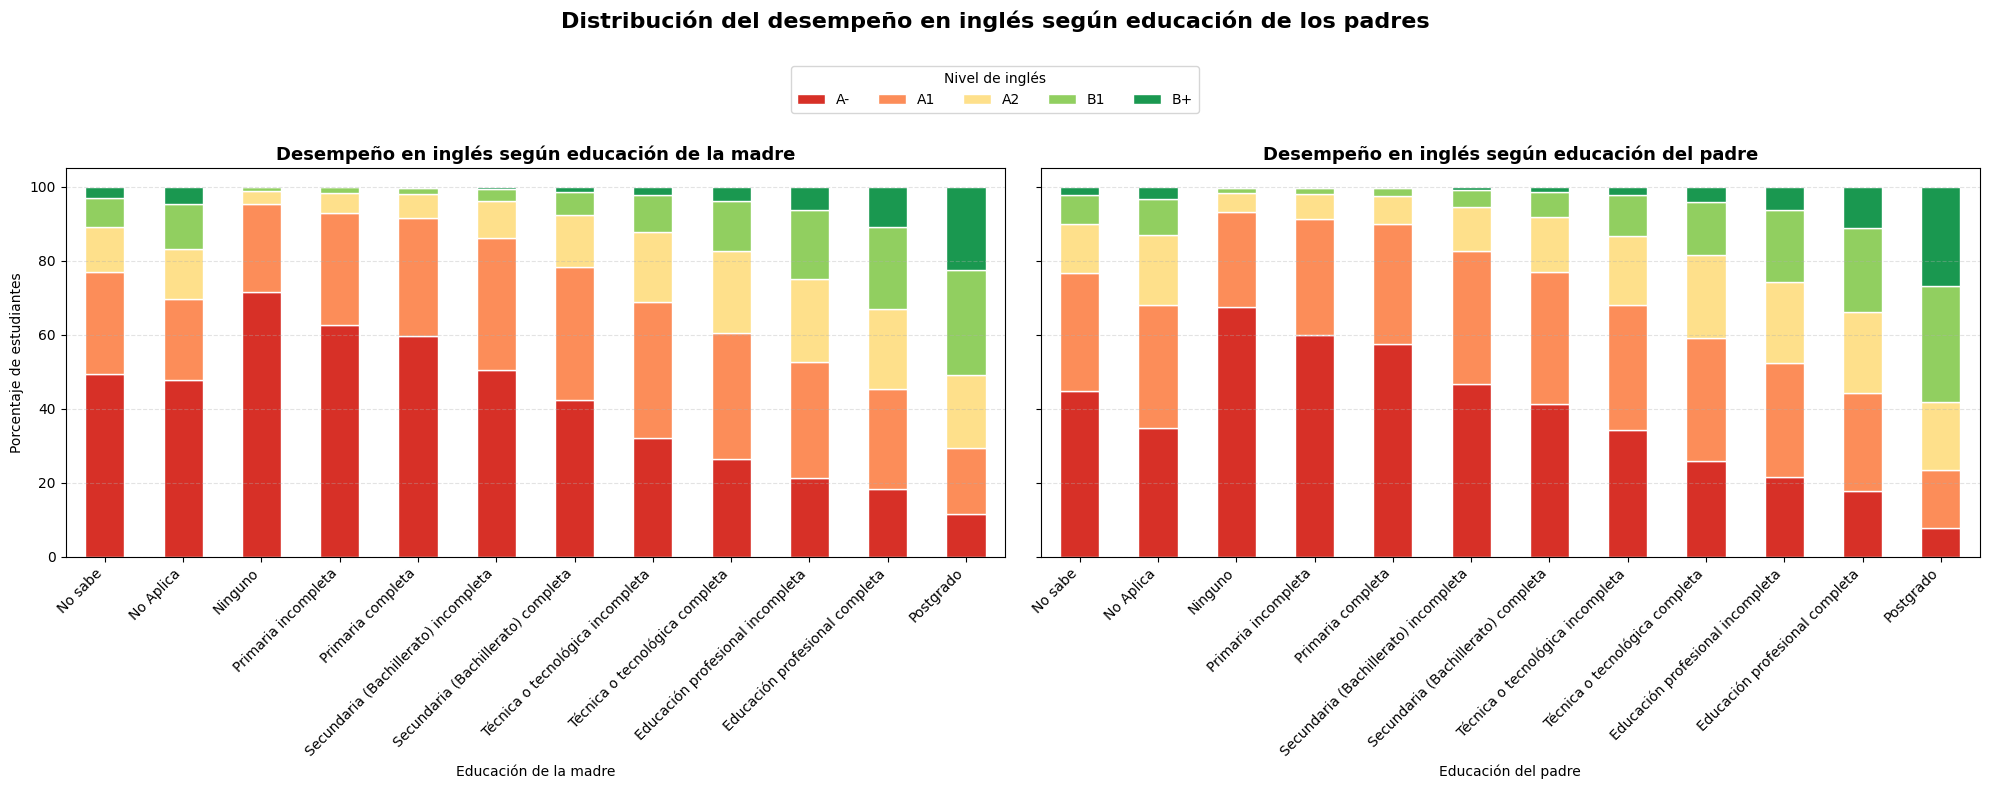

In [19]:
# Orden recomendado de niveles de inglés
orden_niveles = ["A-", "A1", "A2", "B1", "B+"]

# Colores de menor a mayor desempeño
colores = [
    "#d73027",  # A-
    "#fc8d59",  # A1
    "#fee08b",  # A2
    "#91cf60",  # B1
    "#1a9850"   # B+
]

# Crear tablas porcentuales
tabla_madre = pd.crosstab(
    data["FAMI_EDUCACIONMADRE"],
    data["DESEMP_INGLES"],
    normalize="index"
) * 100

tabla_padre = pd.crosstab(
    data["FAMI_EDUCACIONPADRE"],
    data["DESEMP_INGLES"],
    normalize="index"
) * 100

# Reordenar columnas según niveles de inglés existentes
orden_madre = [nivel for nivel in orden_niveles if nivel in tabla_madre.columns]
orden_padre = [nivel for nivel in orden_niveles if nivel in tabla_padre.columns]

tabla_madre = tabla_madre[orden_madre]
tabla_padre = tabla_padre[orden_padre]

# Orden recomendado de niveles educativos
# "No sabe" y "No Aplica" aparecen primero
orden_educacion = [
    "No sabe",
    "No Aplica",
    "Ninguno",
    "Primaria incompleta",
    "Primaria completa",
    "Secundaria (Bachillerato) incompleta",
    "Secundaria (Bachillerato) completa",
    "Técnica o tecnológica incompleta",
    "Técnica o tecnológica completa",
    "Educación profesional incompleta",
    "Educación profesional completa",
    "Postgrado"
]

# Ordenar filas madre
orden_madre_filas = [x for x in orden_educacion if x in tabla_madre.index]
otros_madre = [x for x in tabla_madre.index if x not in orden_madre_filas]
tabla_madre = tabla_madre.loc[orden_madre_filas + otros_madre]

# Ordenar filas padre
orden_padre_filas = [x for x in orden_educacion if x in tabla_padre.index]
otros_padre = [x for x in tabla_padre.index if x not in orden_padre_filas]
tabla_padre = tabla_padre.loc[orden_padre_filas + otros_padre]

# Crear figura con dos gráficas
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Gráfica madre
tabla_madre.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=colores[:len(orden_madre)],
    edgecolor="white"
)

axes[0].set_title(
    "Desempeño en inglés según educación de la madre",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Educación de la madre")
axes[0].set_ylabel("Porcentaje de estudiantes")
axes[0].grid(axis="y", linestyle="--", alpha=0.35)

# Gráfica padre
tabla_padre.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=colores[:len(orden_padre)],
    edgecolor="white"
)

axes[1].set_title(
    "Desempeño en inglés según educación del padre",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Educación del padre")
axes[1].set_ylabel("")
axes[1].grid(axis="y", linestyle="--", alpha=0.35)

# Rotar etiquetas para que se lean mejor
for ax in axes:
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )

# Dejar una sola leyenda general
handles, labels = axes[1].get_legend_handles_labels()

axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.legend(
    handles,
    labels,
    title="Nivel de inglés",
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 1.05)
)

plt.suptitle(
    "Distribución del desempeño en inglés según educación de los padres",
    fontsize=16,
    fontweight="bold",
    y=1.12
)

plt.tight_layout()
plt.show()

In [20]:
tabla_jornada = pd.crosstab(
    data["COLE_JORNADA"],
    data["DESEMP_INGLES"],
    normalize="index"
) * 100

tabla_jornada

DESEMP_INGLES,A-,A1,A2,B+,B1
COLE_JORNADA,,,,,
COMPLETA,40.665216,28.704226,12.521157,6.754252,11.355149
MAÑANA,41.513428,35.388179,14.026035,1.769673,7.302686
NOCHE,73.495137,22.478752,2.961535,0.131429,0.933146
SABATINA,73.939365,21.510665,3.410112,0.217566,0.922291
TARDE,47.185227,36.502408,11.366663,0.591640,4.354062
UNICA,38.639684,33.834749,19.273849,1.001028,7.250690


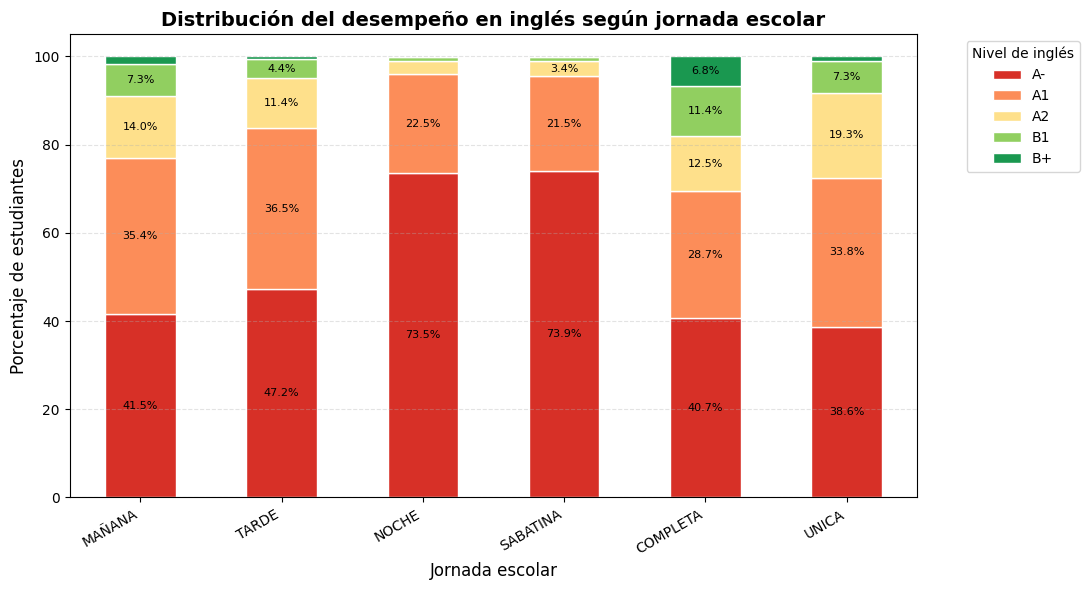

In [21]:
tabla_jornada_graf = tabla_jornada.copy()

# Orden recomendado de niveles de inglés
orden_niveles = ["A-", "A1", "A2", "B1", "B+"]

# Mantener solo los niveles que existan en la tabla
orden_niveles = [
    nivel for nivel in orden_niveles
    if nivel in tabla_jornada_graf.columns
]

tabla_jornada_graf = tabla_jornada_graf[orden_niveles]

# Orden recomendado de jornadas
orden_jornada = [
    "MAÑANA",
    "TARDE",
    "NOCHE",
    "SABATINA",
    "COMPLETA",
    "UNICA"
]

# Mantener solo las jornadas existentes
orden_jornada = [
    jornada for jornada in orden_jornada
    if jornada in tabla_jornada_graf.index
]

# Agregar cualquier otra categoría al final
otras_jornadas = [
    jornada for jornada in tabla_jornada_graf.index
    if jornada not in orden_jornada
]

tabla_jornada_graf = tabla_jornada_graf.loc[orden_jornada + otras_jornadas]

# Colores de menor a mayor desempeño
colores = [
    "#d73027",  # A-
    "#fc8d59",  # A1
    "#fee08b",  # A2
    "#91cf60",  # B1
    "#1a9850"   # B+
]

# Crear gráfica
ax = tabla_jornada_graf.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=colores[:len(orden_niveles)],
    edgecolor="white"
)

# Títulos y etiquetas
plt.title(
    "Distribución del desempeño en inglés según jornada escolar",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Jornada escolar", fontsize=12)
plt.ylabel("Porcentaje de estudiantes", fontsize=12)

plt.xticks(rotation=30, ha="right")
plt.yticks(fontsize=10)

# Leyenda
plt.legend(
    title="Nivel de inglés",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Cuadrícula suave
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Agregar porcentajes dentro de las barras
for container in ax.containers:
    labels = [
        f"{valor:.1f}%" if valor >= 3 else ""
        for valor in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8,
        color="black"
    )

plt.tight_layout()
plt.show()

# Conclusiones del análisis de datos

El conjunto de datos contiene 346.512 registros y 51 variables, con información del estudiante, el colegio, el contexto familiar y los resultados de la prueba Saber 11. Para la pregunta de negocio seleccionada, la variable objetivo es DESEMP_INGLES, la cual representa el nivel de desempeño en inglés del estudiante. Esta variable tiene cinco categorías: A-, A1, A2, B1 y B+.

El análisis mostró que la variable objetivo está fuertemente desbalanceada. La mayor parte de los estudiantes se concentra en los niveles bajos: A- representa aproximadamente 45,9% y A1 aproximadamente 32,3%. En cambio, los niveles superiores tienen mucha menor participación: B1 representa cerca de 7,0% y B+ apenas 2,46%. Esto es importante porque un modelo de clasificación podría aprender a predecir mejor las clases mayoritarias y fallar en las clases superiores.

También se encontraron 73.529 registros duplicados completos, equivalentes aproximadamente al 21,22% de la base. Esto indica que una parte importante de los datos está repetida exactamente igual. Si estos duplicados se mantienen, el modelo puede aprender patrones repetidos artificialmente y sus métricas podrían verse infladas, dando una impresión de mejor desempeño del que realmente tendría con datos nuevos.

En cuanto a valores faltantes, DESEMP_INGLES tiene muy pocos nulos, aproximadamente 0,01%, por lo que se pueden eliminar esos registros sin afectar el tamaño de la base. Sin embargo, algunas variables predictoras sí presentan nulos relevantes. Por ejemplo, COLE_BILINGUE tiene aproximadamente 12,31% de valores faltantes, mientras que variables familiares como FAMI_EDUCACIONPADRE, FAMI_EDUCACIONMADRE, FAMI_ESTRATOVIVIENDA, FAMI_TIENECOMPUTADOR y FAMI_TIENEINTERNET tienen porcentajes menores, pero deben ser tratadas antes del modelamiento.

El análisis exploratorio también muestra que variables como COLE_BILINGUE, COLE_NATURALEZA, FAMI_TIENECOMPUTADOR, FAMI_ESTRATOVIVIENDA, FAMI_EDUCACIONMADRE, FAMI_EDUCACIONPADRE y COLE_JORNADA parecen estar asociadas con diferencias importantes en el desempeño en inglés. Por ejemplo, los colegios bilingües tienen una mayor proporción de estudiantes en niveles altos como B1 y B+, mientras que los estudiantes sin computador en casa se concentran más en niveles bajos como A-.